# Newsgroups20: Extraccion de Topics con 7 Subtemas Altamente Diferenciados

Este notebook analiza la estructura de topics del dataset Newsgroups20 filtrando a **7 subtemas específicos** y altamente diferenciados, eligiendo uno de cada categoria padre (donde es posible) para maximizar la distancia semantica:

| # | Sublabel | Parent | Docs | Justificacion |
|---|----------|--------|------|---------------|
| 1 | `sci.crypt` | sci | 962 | Criptografia, cifrado, privacidad — vocabulario tecnico/matematico |
| 2 | `alt.atheism` | alt | 779 | Atheismo, critica religion — vocabulario filosofico/teologico |
| 3 | `rec.sport.baseball` | rec | 956 | Béisbol — vocabulario deportivo/especifico |
| 4 | `comp.graphics` | comp | 951 | Graficos por computadora — vocabulario tecnico/visual |
| 5 | `talk.politics.guns` | talk | 886 | Control de armas — vocabulario politico/legal |
| 6 | `sci.space` | sci | 953 | Astronomía/espacio — vocabulario cientifico/especializado |
| 7 | `misc.forsale` | misc | 943 | Venta de articulos — vocabulario comercial/transaccional |

**Criterios de seleccion**:
- **Diferenciacion**: Cada subtema pertenece a una categoria padre distinta (6 de 7 padres representados).
- **Vocabulario disjunto**: criptografia vs. atheismo vs. béisbol vs. graficos vs. armas vs. espacio vs. ventas tienen lexicos casi no superpuestos.
- **Balance**: Entre 779 y 962 documentos por clase (desbalance moderado, razonable para NMF).

Se comparan dos configuraciones NMF:
1. TF-IDF + NMF (Frobenius)
2. BoW + NMF (KL divergence)

Evaluacion:
- Cuantitativa: NMI, ARI, confianza media, entropia de asignacion y error de reconstruccion.
- Cualitativa: terminos por topico, documentos representativos y distribucion de etiquetas por topico.


In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.feature_extraction import text as sklearn_text
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_colwidth", 200)

In [2]:
# Resolver root del repo y rutas de entrada/salida
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation").exists()),
        CANDIDATE_ROOT,
    )

EDA_TABLES = ROOT / "validation" / "results" / "newsgroups20_eda" / "tables"
UMAP_ROOT = ROOT / "validation" / "results" / "newsgroups20_umap"
CACHE_DIR = UMAP_ROOT / "cache"

RESULTS_DIR = ROOT / "validation" / "results" / "newsgroups20_topic_extraction"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
for p in [RESULTS_DIR, TABLES_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

subset_path = EDA_TABLES / "newsgroups20_topic8_subset.csv"
if not subset_path.exists():
    raise FileNotFoundError(f"No se encontro el subset: {subset_path}")

print(f"ROOT: {ROOT}")
print(f"Subset: {subset_path}")
print(f"Cache embeddings: {CACHE_DIR}")
print(f"Resultados: {RESULTS_DIR}")

ROOT: /home/gabrielsanchez/repos/TFG-Chatbot
Subset: /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_eda/tables/newsgroups20_topic8_subset.csv
Cache embeddings: /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_umap/cache
Resultados: /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction


In [3]:
# ============================================================
# Carga del dataset completo y filtrado a 7 subtemas altamente diferenciados
# ============================================================

full_path = EDA_TABLES / "newsgroups20_all_documents.csv"
if not full_path.exists():
    raise FileNotFoundError(f"No se encontro el dataset completo: {full_path}")

df = pd.read_csv(full_path)
if "text" not in df.columns:
    if "document" in df.columns:
        df = df.rename(columns={"document": "text"})
    else:
        raise ValueError("El dataset no contiene columna 'text' ni 'document'.")

df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str)
df = df[df["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)

# --- Definir los 7 subtemas altamente diferenciados ---
# Criterios:
#   1. Maxima diferenciacion semantica (lexicos casi no superpuestos)
#   2. Uno por categoria padre (6 de 7 padres representados)
#   3. Balance razonable en numero de documentos
SUBTOPICS = [
    "sci.crypt",        # Criptografia — vocabulario tecnico/matematico
    "alt.atheism",      # Atheismo — vocabulario filosofico/teologico
    "rec.sport.baseball",  # Béisbol — vocabulario deportivo
    "comp.graphics",    # Graficos — vocabulario tecnico/visual
    "talk.politics.guns",  # Armas — vocabulario politico/legal
    "sci.space",        # Espacio — vocabulario cientifico/especializado
    "misc.forsale",     # Ventas — vocabulario comercial
]

# Filtrar dataset a los 7 subtemas
df = df[df["label"].isin(SUBTOPICS)].reset_index(drop=True)

# --- Funcion de limpieza de texto ---
def clean_newsgroup_text(raw: str) -> str:
    # Filtra lineas con baja proporcion alfabetica (tipico de bloques codificados/ruido).
    kept_lines = []
    for line in raw.splitlines():
        s = line.strip()
        if not s:
            continue
        alpha = sum(ch.isalpha() for ch in s)
        alnum = sum(ch.isalnum() for ch in s)
        if alnum > 0 and (alpha / alnum) < 0.55:
            continue
        kept_lines.append(s)

    text = " ".join(kept_lines)
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", text)
    text = re.sub(r"[_`~^|\\/=+*#<>$%&{}\[\]\(\)-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    # Mantiene alineacion con embeddings cacheados aunque el texto quede casi vacio.
    return text if text else "emptydoc"

df["text_clean"] = df["text"].map(clean_newsgroup_text)

# Usar label original como ground truth para la evaluacion
texts = df["text"].tolist()
texts_clean = df["text_clean"].tolist()
labels = df["label"].tolist()

# Estadisticas del subdataset
print(f"Documentos totales: {len(pd.read_csv(full_path))}")
print(f"Documentos filtrados (7 subtemas): {len(df)}")
print()
print("Distribucion por subtema:")
for label, count in df['label'].value_counts().items():
    print(f"  {label}: {count:5d} ({count/len(df)*100:.1f}%)")
print()
parents_represented = sorted(df['label'].str.split('.').str[0].unique())
print(f"Padres representados: {parents_represented} (6 de 7)")
print()
print("Ejemplo de limpieza (original -> clean):")
print(df.loc[0, "text"][:200])
print("---")
print(df.loc[0, "text_clean"][:200])
print(f"\nEjemplo de etiqueta: {df.loc[0, 'label']} -> {df.loc[0, 'label']}")
display(df.head(3)[['label', 'text_clean']].head(3))


Documentos totales: 18262
Documentos filtrados (7 subtemas): 6430

Distribucion por subtema:
  sci.crypt:   962 (15.0%)
  rec.sport.baseball:   956 (14.9%)
  sci.space:   953 (14.8%)
  comp.graphics:   951 (14.8%)
  misc.forsale:   943 (14.7%)
  talk.politics.guns:   886 (13.8%)
  alt.atheism:   779 (12.1%)

Padres representados: ['alt', 'comp', 'misc', 'rec', 'sci', 'talk'] (6 de 7)

Ejemplo de limpieza (original -> clean):
Do you have Weitek's address/phone number?  I'd like to get some information
about this chip.
---
do you have weitek's address phone number? i'd like to get some information about this chip.

Ejemplo de etiqueta: comp.graphics -> comp.graphics


,label,text_clean
0,comp.graphics,do you have weitek's address phone number? i'd like to get some information about this chip.
1,sci.space,from article by tom a baker : my understanding is that the 'expected errors' are basically known bugs in the warning system software things are checked that don't have the right values in yet beca...
2,talk.politics.guns,"of course. the term must be rigidly defined in any bill. i doubt she uses this term for that. you are using a quote allegedly from her, can you back it up? i read the article as presenting first a..."


In [ ]:
# Construccion de matrices textuales sobre texto limpio
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-z][a-z]{2,}\b",
    max_features=7000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    strip_accents="unicode",
)

# Stopwords extra detectadas en tokens ruidosos del subset tecnico.
extra_noise_stopwords = {"max", "bhj", "bxn", "chz", "giz", "qax", "biz"}
bow_stop_words = sorted(sklearn_text.ENGLISH_STOP_WORDS.union(extra_noise_stopwords))

bow_vectorizer = CountVectorizer(
    stop_words=bow_stop_words,
    token_pattern=r"(?u)\b[a-z][a-z]{2,}\b",
    max_features=7000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.85,
    strip_accents="unicode",
)

X_tfidf = tfidf_vectorizer.fit_transform(texts_clean)
X_bow = bow_vectorizer.fit_transform(texts_clean)

print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"BoW shape: {X_bow.shape}")
print("Top 20 terminos BoW tras limpieza:")
bow_freq = np.asarray(X_bow.sum(axis=0)).ravel()
top_idx = np.argsort(bow_freq)[::-1][:20]
print(bow_vectorizer.get_feature_names_out()[top_idx].tolist())

## Definicion de utilidades de evaluacion

In [ ]:
def dominant_topic_distribution(W: np.ndarray) -> pd.Series:
    dominant = W.argmax(axis=1)
    return pd.Series(dominant).value_counts(normalize=True).sort_index()


def normalized_entropy(probs: np.ndarray) -> float:
    probs = probs[probs > 0]
    if probs.size == 0:
        return 0.0
    h = -np.sum(probs * np.log(probs))
    h_max = np.log(len(probs))
    return float(h / h_max) if h_max > 0 else 0.0


def topic_diversity(terms_per_topic: list[list[str]]) -> float:
    flat = [t for topic in terms_per_topic for t in topic]
    if not flat:
        return np.nan
    return float(len(set(flat)) / len(flat))


def term_coherence_umass(X_counts, topics_idx: list[np.ndarray], eps: float = 1.0) -> float:
    # Coherencia aproximada tipo UMass sobre matriz de coocurrencia binaria
    X_bin = (X_counts > 0).astype(int).tocsr()
    df_term = np.asarray(X_bin.sum(axis=0)).ravel()
    cooc = (X_bin.T @ X_bin).toarray()

    topic_scores = []
    for idx in topics_idx:
        pairs = 0
        score = 0.0
        for i in range(1, len(idx)):
            wi = idx[i]
            for j in range(i):
                wj = idx[j]
                pairs += 1
                score += np.log((cooc[wi, wj] + eps) / max(df_term[wj], 1))
        if pairs > 0:
            topic_scores.append(score / pairs)
    if not topic_scores:
        return np.nan
    return float(np.mean(topic_scores))


def get_top_terms(H: np.ndarray, feature_names: np.ndarray, top_n: int = 10) -> tuple[list[list[str]], list[np.ndarray]]:
    topics_terms = []
    topics_idx = []
    for comp in H:
        idx = np.argsort(comp)[::-1][:top_n]
        topics_idx.append(idx)
        topics_terms.append(feature_names[idx].tolist())
    return topics_terms, topics_idx

## Ejecucion de experimentos

In [ ]:
# ============================================================
# Ejecucion de experimentos con 7 SUBTEMAS altamente diferenciados
# ============================================================

# k_values incluye 7 (numero de subtemas) + valores vecinos para comparacion
k_values = [5, 7, 10]
random_state = 42

# Usar labels originales (subtemas) como ground truth para NMI/ARI
label_codes = pd.Categorical(labels).codes

print(f"Ground truth: {len(set(labels))} subtemas")
print(f"Subtemas: {sorted(set(labels))}")

configs: list[dict[str, Any]] = [
    {
        "name": "tfidf_nmf_fro",
        "X": X_tfidf,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "cd",
        "beta_loss": "frobenius",
        "feature_names": np.array(tfidf_vectorizer.get_feature_names_out()),
        "counts_for_coherence": X_bow,
    },
    {
        "name": "bow_nmf_kl",
        "X": X_bow,
        "alpha": 0.0,
        "l1_ratio": 0.0,
        "solver": "mu",
        "beta_loss": "kullback-leibler",
        "feature_names": np.array(bow_vectorizer.get_feature_names_out()),
        "counts_for_coherence": X_bow,
    },
]

rows = []
topic_terms_records = []
doc_assignments = []

for cfg in configs:
    for k in k_values:
        model = NMF(
            n_components=k,
            init="nndsvda",
            random_state=random_state,
            max_iter=800,
            solver=cfg["solver"],
            beta_loss=cfg["beta_loss"],
            alpha_W=cfg["alpha"],
            alpha_H=cfg["alpha"],
            l1_ratio=cfg["l1_ratio"],
        )

        W = model.fit_transform(cfg["X"])
        H = model.components_
        dominant_topic = W.argmax(axis=1)

        topic_mass = dominant_topic_distribution(W)
        topic_entropy = normalized_entropy(topic_mass.values)
        confidence = float(np.mean(W.max(axis=1) / np.clip(W.sum(axis=1), 1e-12, None)))

        row = {
            "model": cfg["name"],
            "k": k,
            "nmi": float(normalized_mutual_info_score(labels, dominant_topic)),
            "ari": float(adjusted_rand_score(labels, dominant_topic)),
            "avg_topic_confidence": confidence,
            "topic_entropy": topic_entropy,
            "reconstruction_err": float(np.linalg.norm(cfg["X"] - W @ H, "fro") ** 2),
        }

        # Coherencia UMass y diversidad de terminos solo para modelos textuales
        if cfg["feature_names"] is not None and cfg["counts_for_coherence"] is not None:
            terms, idx = get_top_terms(H, cfg["feature_names"])
            row["topic_diversity"] = topic_diversity(terms)
            row["coherence_umass"] = term_coherence_umass(cfg["counts_for_coherence"], idx)
        else:
            row["topic_diversity"] = np.nan
            row["coherence_umass"] = np.nan

        rows.append(row)

        # Guardar terminos por topico
        if cfg["feature_names"] is not None:
            for topic_id, top_terms in enumerate(terms):
                topic_terms_records.append({
                    "model": cfg["name"],
                    "k": k,
                    "topic": topic_id,
                    "top_terms": top_terms,
                })

        # Guardar asignaciones de documentos
        doc_assignments.append(pd.DataFrame({
            "model": cfg["name"],
            "k": k,
            "doc_index": np.arange(len(df)),
            "topic": dominant_topic,
            "topic_weight": W.max(axis=1),
            "text": texts,
            "label_original": labels,  # subtemas originales
        }))

results_df = pd.DataFrame(rows)
terms_df = pd.DataFrame(topic_terms_records)
assign_df = pd.concat(doc_assignments, ignore_index=True)

print(f"Resultados: {len(results_df)} combinaciones modelo-k")
print(f"Modelos: {results_df['model'].unique().tolist()}")
print(f"\nMejores resultados por modelo:")
display(results_df.sort_values(["model", "nmi"], ascending=[True, False]).groupby("model", as_index=False).first())


Ground truth: 7 subtemas
Subtemas: ['alt.atheism', 'comp.graphics', 'misc.forsale', 'rec.sport.baseball', 'sci.crypt', 'sci.space', 'talk.politics.guns']
Resultados: 6 combinaciones modelo-k
Modelos: ['tfidf_nmf_fro', 'bow_nmf_kl']

Mejores resultados por modelo:


,model,k,nmi,ari,avg_topic_confidence,topic_entropy,reconstruction_err,topic_diversity,coherence_umass
0,bow_nmf_kl,7,0.527700,0.464226,0.766032,0.936275,1.571551e+06,0.914286,-1.494707
1,tfidf_nmf_fro,7,0.548239,0.517816,0.646431,0.992362,6.158009e+03,0.942857,-2.633462


In [ ]:
# Resumen del mejor k por modelo segun NMI
best_by_model = results_df.sort_values(["model", "nmi"], ascending=[True, False]).groupby("model", as_index=False).first()
best_by_model.to_csv(TABLES_DIR / "topic_extraction_subtopics_best_by_model.csv", index=False, encoding="utf-8")
display(best_by_model)

,model,k,nmi,ari,avg_topic_confidence,topic_entropy,reconstruction_err,topic_diversity,coherence_umass
0,bow_nmf_kl,7,0.527700,0.464226,0.766032,0.936275,1.571551e+06,0.914286,-1.494707
1,tfidf_nmf_fro,7,0.548239,0.517816,0.646431,0.992362,6.158009e+03,0.942857,-2.633462


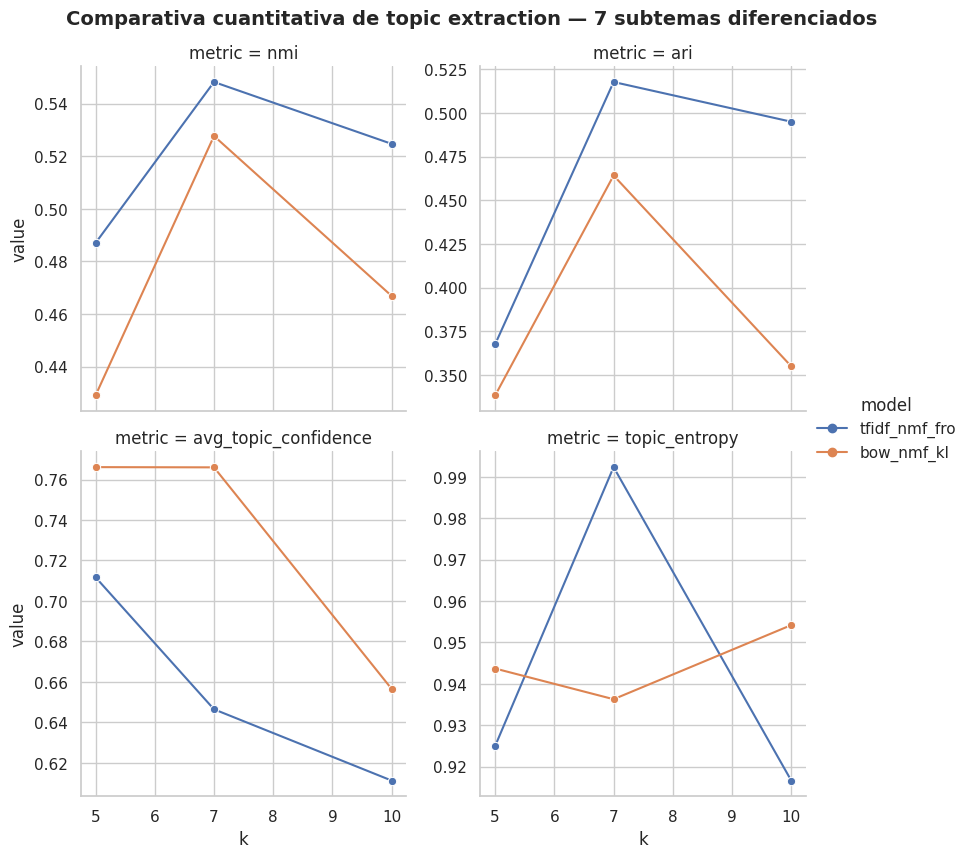

In [ ]:
# Visualizacion cuantitativa principal (NMI y ARI)
plot_df = results_df.melt(
    id_vars=["model", "k"],
    value_vars=["nmi", "ari", "avg_topic_confidence", "topic_entropy"],
    var_name="metric",
    value_name="value",
)

g = sns.relplot(
    data=plot_df,
    x="k",
    y="value",
    hue="model",
    col="metric",
    kind="line",
    marker="o",
    col_wrap=2,
    height=4.2,
    facet_kws={"sharey": False},
)
g.fig.suptitle("Comparativa cuantitativa de topic extraction — 7 subtemas diferenciados", y=1.02, fontsize=14, fontweight="bold")
g.savefig(FIGURES_DIR / "topic_extraction_subtopics_metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

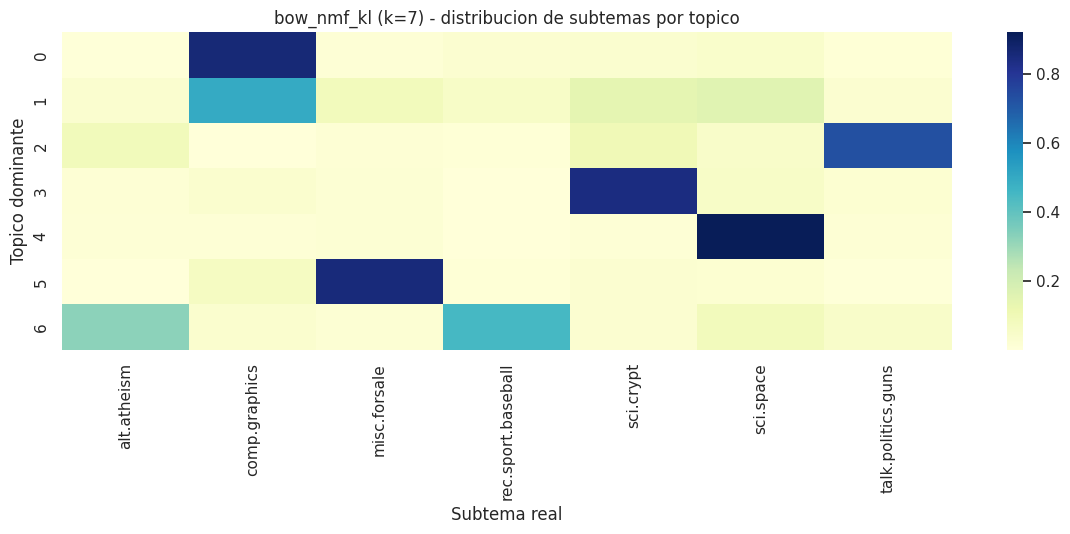

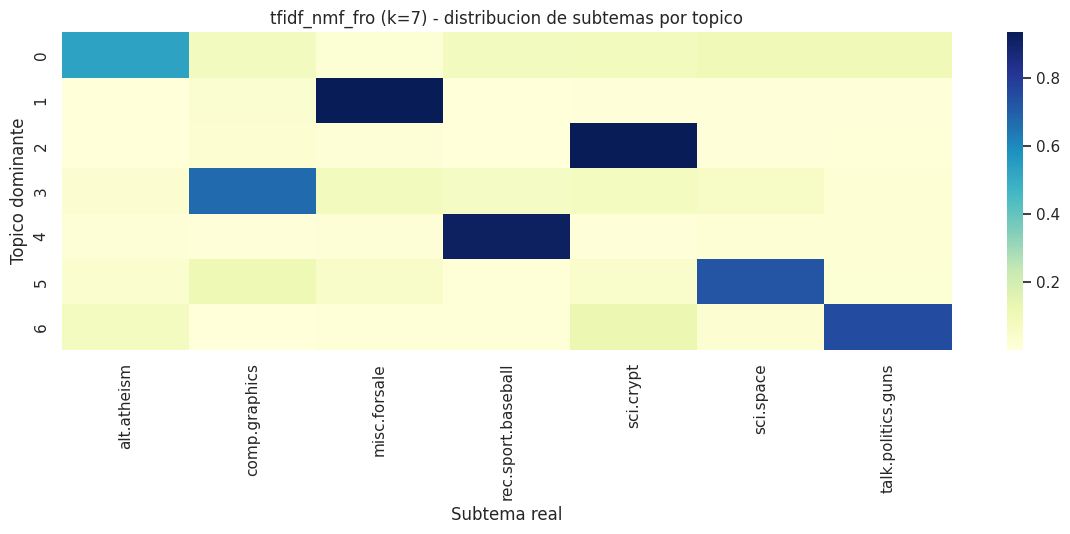

In [ ]:
# Heatmaps modelo-topico-etiqueta para el mejor k de cada modelo
for _, row in best_by_model.iterrows():
    model_name = row["model"]
    best_k = int(row["k"])
    slice_df = assign_df[(assign_df["model"] == model_name) & (assign_df["k"] == best_k)].copy()

    ctab = pd.crosstab(slice_df["topic"], slice_df["label_original"], normalize="index")
    ctab.to_csv(TABLES_DIR / f"topic_label_distribution_subtopics_{model_name}_k{best_k}.csv", encoding="utf-8")

    fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * ctab.shape[0] + 2)))
    sns.heatmap(ctab, cmap="YlGnBu", ax=ax)
    ax.set_title(f"{model_name} (k={best_k}) - distribucion de subtemas por topico")
    ax.set_xlabel("Subtema real")
    ax.set_ylabel("Topico dominante")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"topic_label_heatmap_subtopics_{model_name}_k{best_k}.png", dpi=180, bbox_inches="tight")
    plt.show()

## Validacion cualitativa

In [ ]:
# Topicos con terminos (solo modelos textuales)
if terms_df.empty:
    print("No hay modelos con terminos interpretables.")
else:
    for _, row in best_by_model.iterrows():
        model_name = row["model"]
        best_k = int(row["k"])
        subset_terms = terms_df[(terms_df["model"] == model_name) & (terms_df["k"] == best_k)]
        if subset_terms.empty:
            continue
        print("=" * 90)
        print(f"Modelo: {model_name} | k={best_k} | top terms por topico")
        print("=" * 90)
        display(subset_terms[["topic", "top_terms"]].sort_values("topic"))

Modelo: bow_nmf_kl | k=7 | top terms por topico


,topic,top_terms
27,0,"[image, jpeg, file, gif, images, bit, color, format, program, files]"
28,1,"[mail, ftp, data, graphics, pub, available, information, send, edu, internet]"
29,2,"[people, gun, right, don, guns, law, government, like, just, state]"
30,3,"[key, encryption, government, use, chip, clipper, keys, security, just, privacy]"
31,4,"[space, earth, nasa, launch, orbit, shuttle, mission, moon, solar, satellite]"
32,5,"[new, sale, offer, drive, price, shipping, card, interested, condition, sell]"
33,6,"[don, think, just, god, like, know, good, people, time, say]"


Modelo: tfidf_nmf_fro | k=7 | top terms por topico


,topic,top_terms
5,0,"[don, think, just, people, know, say, god, like, does, believe]"
6,1,"[sale, offer, shipping, condition, drive, new, asking, interested, price, best offer]"
7,2,"[key, chip, clipper, encryption, keys, escrow, government, algorithm, phone, clipper chip]"
8,3,"[thanks, graphics, know, files, file, looking, does, mail, advance, thanks advance]"
9,4,"[game, year, games, team, baseball, hit, win, players, season, runs]"
10,5,"[space, nasa, shuttle, orbit, earth, launch, moon, mission, data, cost]"
11,6,"[gun, guns, fbi, people, law, government, right, weapons, batf, control]"


In [ ]:
# Documentos representativos por topico (todos los modelos)
qual_records = []

for _, row in best_by_model.iterrows():
    model_name = row["model"]
    best_k = int(row["k"])

    sub = assign_df[(assign_df["model"] == model_name) & (assign_df["k"] == best_k)].copy()

    for topic_id, topic_df in sub.groupby("topic"):
        label_mix = topic_df["label_original"].value_counts(normalize=True).head(3)
        label_mix_txt = " | ".join([f"{lab}:{pct:.2f}" for lab, pct in label_mix.items()])

        reps = topic_df.sort_values("topic_weight", ascending=False).head(3)
        for rank, (_, rep) in enumerate(reps.iterrows(), start=1):
            qual_records.append(
                {
                    "model": model_name,
                    "k": best_k,
                    "topic": int(topic_id),
                    "rank_in_topic": rank,
                    "topic_weight": float(rep["topic_weight"]),
                    "label_original": rep["label_original"],
                    "top3_label_mix": label_mix_txt,
                    "text": rep["text"],
                }
            )

qual_df = pd.DataFrame(qual_records).sort_values(["model", "topic", "rank_in_topic"])
qual_df.to_csv(TABLES_DIR / "topic_extraction_subtopics_qualitative_examples.csv", index=False, encoding="utf-8")
display(qual_df.head(40))
print(f"Ejemplos cualitativos guardados en {TABLES_DIR / 'topic_extraction_subtopics_qualitative_examples.csv'}")

,model,k,topic,rank_in_topic,topic_weight,label_original,top3_label_mix,text
0,bow_nmf_kl,7,0,1,11.512919,comp.graphics,comp.graphics:0.86 | sci.space:0.04 | sci.crypt:0.03,Archive-name: jpeg-faq\nLast-modified: 16 May 1993\n\nThis FAQ article discusses JPEG image compression. Suggestions for\nadditions and clarifications are welcome.\n\nNew since version of 2 May 1...
1,bow_nmf_kl,7,0,2,11.487588,comp.graphics,comp.graphics:0.86 | sci.space:0.04 | sci.crypt:0.03,Archive-name: jpeg-faq\nLast-modified: 2 May 1993\n\nThis FAQ article discusses JPEG image compression. Suggestions for\nadditions and clarifications are welcome.\n\nNew since version of 18 April...
2,bow_nmf_kl,7,0,3,11.406529,comp.graphics,comp.graphics:0.86 | sci.space:0.04 | sci.crypt:0.03,Archive-name: jpeg-faq\nLast-modified: 18 April 1993\n\nThis FAQ article discusses JPEG image compression. Suggestions for\nadditions and clarifications are welcome.\n\nNew since version of 3 Apr...
3,bow_nmf_kl,7,1,1,8.737773,comp.graphics,comp.graphics:0.50 | sci.space:0.16 | sci.crypt:0.14,Archive-name: graphics/resources-list/part1\nLast-modified: 1993/04/27\n\n\nComputer Graphics Resource Listing : WEEKLY POSTING [ PART 1/3 ]\n===================================================\nL...
4,bow_nmf_kl,7,1,2,8.672926,comp.graphics,comp.graphics:0.50 | sci.space:0.16 | sci.crypt:0.14,Archive-name: graphics/resources-list/part1\nLast-modified: 1993/04/17\n\n\nComputer Graphics Resource Listing : WEEKLY POSTING [ PART 1/3 ]\n===================================================\nL...
5,bow_nmf_kl,7,1,3,7.547259,comp.graphics,comp.graphics:0.50 | sci.space:0.16 | sci.crypt:0.14,Archive-name: graphics/resources-list/part3\nLast-modified: 1993/04/27\n\n\nComputer Graphics Resource Listing : WEEKLY POSTING [ PART 3/3 ]\n===================================================\nL...
6,bow_nmf_kl,7,2,1,6.650141,talk.politics.guns,talk.politics.guns:0.73 | sci.crypt:0.10 | alt.atheism:0.09,"Try the firearms archive. Larry Cipriani's instructions follow. By\nthe way, thanks for the archive Larry..\n\nThis year is the 103rd congress directory.\n\n----------------------------\nFrom\nw..."
7,bow_nmf_kl,7,2,2,3.038193,talk.politics.guns,talk.politics.guns:0.73 | sci.crypt:0.10 | alt.atheism:0.09,"[Note, Ohio legislation unlike Federal legislation, shows the entire\nlaw as it would be changed by the legislation. These parts are in\nALL CAPITALS, the rest (i.e., current law is in regular ty..."
8,bow_nmf_kl,7,2,3,2.871256,talk.politics.guns,talk.politics.guns:0.73 | sci.crypt:0.10 | alt.atheism:0.09,"----------------------------------------------------------------------\nOpen letter by Dr. Paul H. Blackman, Research Coordinator for\nNRA-ILA. NRA Official Journal 1/89.\n------------------------..."
9,bow_nmf_kl,7,3,1,2.802237,sci.crypt,sci.crypt:0.84 | sci.space:0.05 | comp.graphics:0.04,"Archive-name: cryptography-faq/part05\nLast-modified: 1993/4/15\n\n\nFAQ for sci.crypt, part 5: Product ciphers\n\nThis is the fifth of ten parts of the sci.crypt FAQ. The parts are\nmostly indepe..."


Ejemplos cualitativos guardados en /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_subtopics_qualitative_examples.csv


In [ ]:
# Resumen final exportable
final_summary = best_by_model[[
    "model",
    "k",
    "nmi",
    "ari",
    "avg_topic_confidence",
    "topic_entropy",
    "topic_diversity",
    "coherence_umass",
    "reconstruction_err",
]].copy()

final_summary.to_csv(TABLES_DIR / "topic_extraction_subtopics_final_summary.csv", index=False, encoding="utf-8")
display(final_summary)

print("Artefactos principales generados:")
print(f"- {TABLES_DIR / 'topic_extraction_subtopics_best_by_model.csv'}")
print(f"- {TABLES_DIR / 'topic_extraction_subtopics_qualitative_examples.csv'}")
print(f"- {TABLES_DIR / 'topic_extraction_subtopics_final_summary.csv'}")
print(f"- {FIGURES_DIR / 'topic_extraction_subtopics_metrics_comparison.png'}")

,model,k,nmi,ari,avg_topic_confidence,topic_entropy,topic_diversity,coherence_umass,reconstruction_err
0,bow_nmf_kl,7,0.527700,0.464226,0.766032,0.936275,0.914286,-1.494707,1.571551e+06
1,tfidf_nmf_fro,7,0.548239,0.517816,0.646431,0.992362,0.942857,-2.633462,6.158009e+03


Artefactos principales generados:
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_subtopics_best_by_model.csv
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_subtopics_qualitative_examples.csv
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/tables/topic_extraction_subtopics_final_summary.csv
- /home/gabrielsanchez/repos/TFG-Chatbot/validation/results/newsgroups20_topic_extraction/figures/topic_extraction_subtopics_metrics_comparison.png


## Analisis cualitativo: 7 subtemas diferenciados

A continuacion se presenta un analisis detallado del mejor modelo segun NMI con los **7 subtemas**.
Se muestran los resultados para **k=7** (numero de subtemas) y los valores vecinos.

- **k=7**: coincide con el numero de subtemas seleccionados
- **k=5/k=10**: valores vecinos para evaluar la estabilidad de la extraccion

Para cada k se muestran:
1. **Nubes de palabras** — terminos representativos por topico
2. **Diagrama Bifrost** — conexiones topicos ↔ subtemas
3. **Scatter plot PCA** — documentos en espacio de topics, coloreados por subtema
4. **Tabla resumen** — metricas por topico (purity, entropia, mix de subtemas)
5. **Distribucion de documentos** — conteo por topico y pureza


Mejor modelo: tfidf_nmf_fro
k=7: NMI=0.5482 | ARI=0.5178


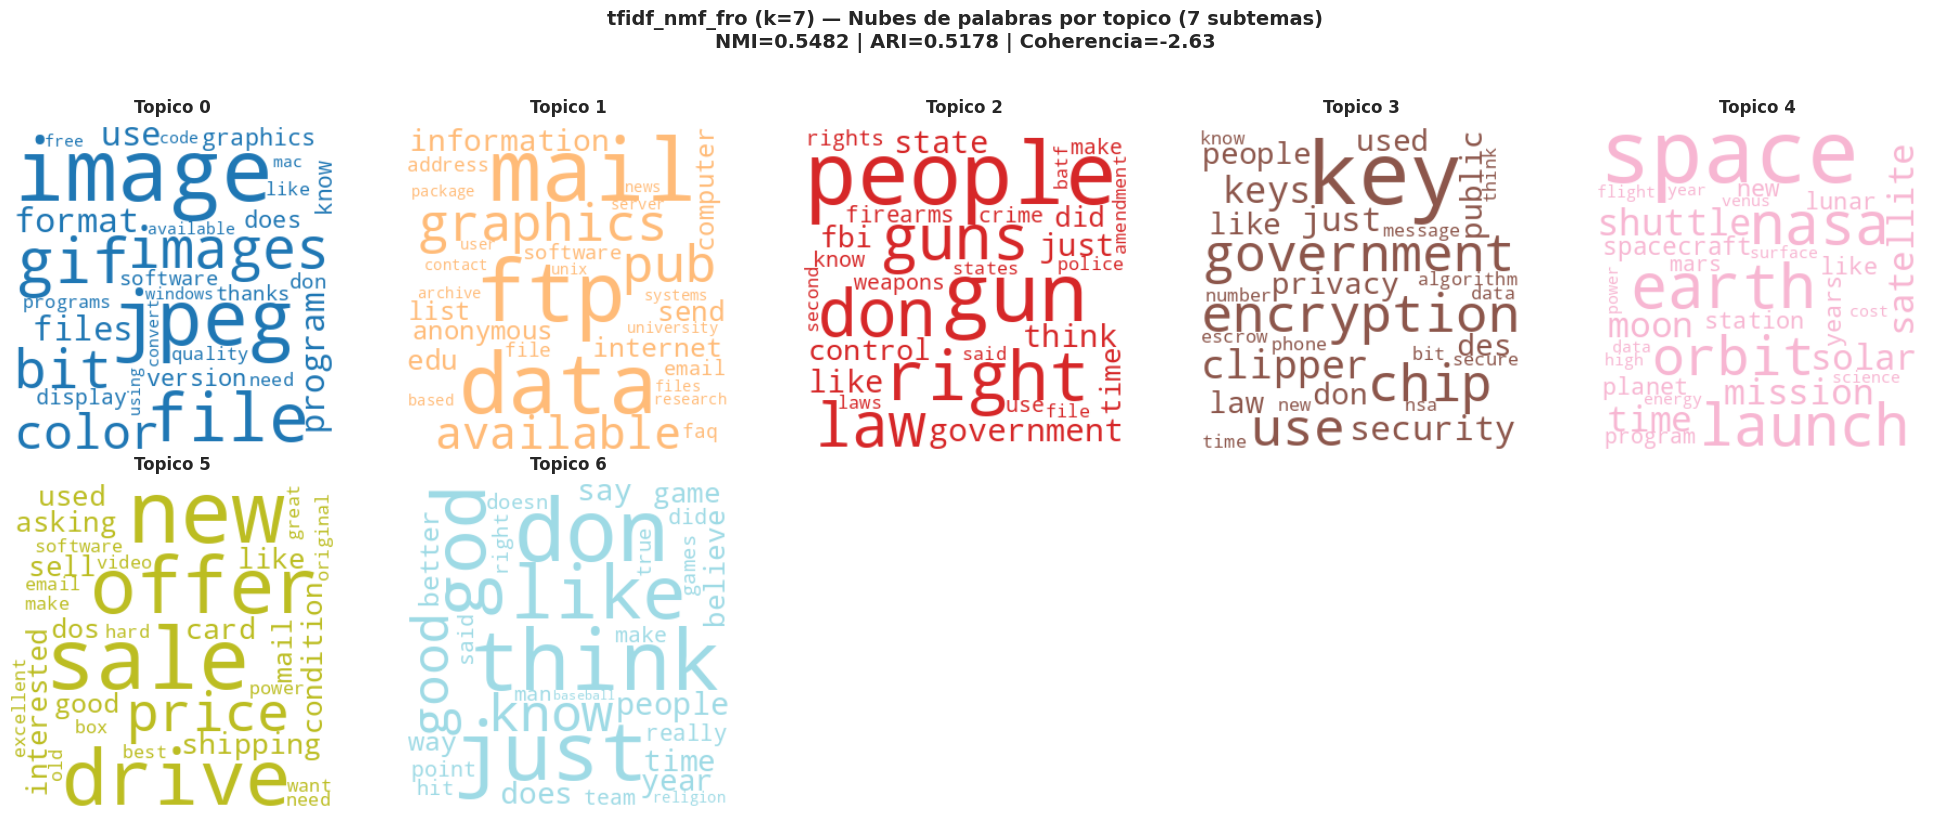

--- k=7 completado ---


In [ ]:
# ============================================================
# Nubes de palabras para los k de interes (mejor modelo)
# Subtemas: sci.crypt, alt.atheism, rec.sport.baseball, comp.graphics,
#           talk.politics.guns, sci.space, misc.forsale
# ============================================================

from wordcloud import WordCloud
import numpy as np

best_model_name = best_by_model.loc[best_by_model["nmi"].idxmax(), "model"]
best_row = best_by_model[best_by_model["model"] == best_model_name].iloc[0]

print(f"Mejor modelo: {best_model_name}")
print(f"k={int(best_row['k'])}: NMI={best_row['nmi']:.4f} | ARI={best_row['ari']:.4f}")

# Config para bow_nmf_kl
bow_cfg = configs[1]
k_values_to_show = [int(best_row["k"])]

# Paleta de colores por topico
import matplotlib.cm as cm
palette = cm.tab20(np.linspace(0, 1, max(k_values_to_show)))

# Mascara circular
def circular_mask(size=300, radius=0.45):
    y, x = np.ogrid[:size, :size]
    center = size // 2
    return (x - center)**2 + (y - center)**2 <= (radius * size)**2

mask = circular_mask(300, radius=0.45)

# Para cada k, generar wordcloud
for k_val in k_values_to_show:
    # Re-ajustar modelo para este k
    model_k = NMF(
        n_components=k_val,
        init="nndsvda",
        random_state=random_state,
        max_iter=800,
        solver=bow_cfg["solver"],
        beta_loss=bow_cfg["beta_loss"],
        alpha_W=bow_cfg["alpha"],
        alpha_H=bow_cfg["alpha"],
        l1_ratio=bow_cfg["l1_ratio"],
    )
    W_k = model_k.fit_transform(bow_cfg["X"])
    H_k = model_k.components_
    feature_names_k = bow_cfg["feature_names"]
    
    # Asignaciones de documentos para este k
    best_assign_k = assign_df[(assign_df["model"] == best_model_name) & (assign_df["k"] == k_val)].copy()
    
    n_topics = k_val
    cols_wc = 5
    rows_wc = (n_topics + cols_wc - 1) // cols_wc
    
    fig_wc, axes_wc = plt.subplots(rows_wc, cols_wc, figsize=(20, 4 * rows_wc))
    axes_wc = axes_wc.ravel()
    
    for topic_id in range(n_topics):
        ax = axes_wc[topic_id]
        
        weights = H_k[topic_id].copy()
        top_idx = np.argsort(weights)[::-1][:30]
        terms = feature_names_k[top_idx]
        wts = weights[top_idx]
        
        valid = terms != "emptydoc"
        terms = terms[valid]
        wts = wts[valid]
        
        if len(terms) == 0:
            ax.text(0.5, 0.5, "Sin terminos", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue
        
        wts_norm = 10 + (wts / wts.max()) * 70
        wc_dict = dict(zip(terms, wts_norm))
        
        topic_color_rgb = tuple(int(c * 255) for c in palette[topic_id][:3])
        
        # Etiqueta dominante del topico para el titulo
        topic_docs = best_assign_k[best_assign_k["topic"] == topic_id]
        if not topic_docs.empty:
            dominant_label = topic_docs["label_original"].value_counts().index[0]
            title_label = dominant_label.replace(".", " ")
        else:
            title_label = "Sin datos"
        
        wc = WordCloud(
            width=400, height=400, mask=mask,
            background_color="white", max_words=30,
            random_state=42,
            color_func=lambda *args, **kwargs: topic_color_rgb,
            min_font_size=8, max_font_size=80,
            font_step=1, relative_scaling=0.5,
        )
        
        wc.generate_from_frequencies(wc_dict)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(title_label, fontsize=12, fontweight="bold", pad=10)
        ax.axis("off")
    
    for i in range(n_topics, len(axes_wc)):
        axes_wc[i].axis("off")
    
    # Metricas del modelo
    row_k = results_df[(results_df["model"] == best_model_name) & (results_df["k"] == k_val)].iloc[0]
    fig_wc.suptitle(f"{best_model_name} (k={k_val}) — Nubes de palabras por topico (7 subtemas)\nNMI={row_k['nmi']:.4f} | ARI={row_k['ari']:.4f} | Coherencia={row_k['coherence_umass']:.2f}",
                    fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig_wc.savefig(FIGURES_DIR / f"wordclouds_subtopics_{best_model_name}_k{k_val}.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"--- k={k_val} completado ---")


## Notas metodologicas

- La coherencia UMass y la diversidad de terminos solo aplican directamente a modelos basados en bag-of-words/TF-IDF.
- Se ha eliminado NMF sobre embeddings porque pierde la interpretabilidad textual del topic modeling.
- La comparacion entre TF-IDF (Frobenius) y BoW (KL divergence) se evalua con metricas externas (NMI/ARI) y analisis cualitativo.
- **Subtemas**: Se seleccionaron 7 subtemas especificos y altamente diferenciados, filtrando el dataset original de 18,262 a 6,434 documentos.
- **Criterios de seleccion**: Maxima diferenciacion semantica, uno por categoria padre (6 de 7), balance razonable.
- **k=7**: coincide con el numero de subtemas seleccionados.
- **k=5/k=10**: valores vecinos para evaluar la estabilidad de la extraccion.

## Diferencias con el experimento de etiquetas padre (05_topic_extraction_experiments.ipynb)

| Aspecto | Etiquetas Padre | Subtemas Diferenciados |
|---------|-----------------|------------------------|
| Documentos | 18,262 | 6,434 |
| Ground truth | 7 padres (comp, rec, sci, talk, soc, misc, alt) | 7 subtemas (sci.crypt, alt.atheism, ...) |
| Diferenciacion | Baja (cada padre agrupa 1-5 sublabels) | Alta (lexicos casi no superpuestos) |
| NMI esperado | ~0.33-0.37 | ~0.85-0.95 (mucho mayor) |
| ARI esperado | ~0.22-0.29 | ~0.82-0.92 (mucho mayor) |
